In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries loaded!")

Libraries loaded!


In [2]:
PATH = 'E:/portfoilo/olist-ecommerce-analysis/data/raw/'

orders   = pd.read_csv(PATH + 'olist_orders_dataset.csv')
items    = pd.read_csv(PATH + 'olist_order_items_dataset.csv')
products = pd.read_csv(PATH + 'olist_products_dataset.csv')
sellers  = pd.read_csv(PATH + 'olist_sellers_dataset.csv')
customers = pd.read_csv(PATH + 'olist_customers_dataset.csv')

# แปลงวันที่
date_cols = ['order_purchase_timestamp',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# กรองเฉพาะ delivered orders ที่มีวันส่งครบ
orders_clean = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notna())
].copy()

# สร้าง target variable
# 1 = ส่งช้า, 0 = ส่งทัน
orders_clean['is_late'] = (
    orders_clean['order_delivered_customer_date'] >
    orders_clean['order_estimated_delivery_date']
).astype(int)

print(f"Orders: {orders_clean.shape[0]:,}")
print(f"Late: {orders_clean['is_late'].sum():,} ({orders_clean['is_late'].mean()*100:.1f}%)")
print(f"On Time: {(orders_clean['is_late']==0).sum():,}")

Orders: 96,470
Late: 7,826 (8.1%)
On Time: 88,644


In [3]:
# รวม items กับ products
items_products = items.merge(products[['product_id','product_weight_g',
                                        'product_length_cm','product_height_cm',
                                        'product_width_cm']], on='product_id')

# สรุปต่อ order
order_features = items_products.groupby('order_id').agg(
    total_items     = ('order_item_id', 'count'),
    total_price     = ('price', 'sum'),
    total_freight   = ('freight_value', 'sum'),
    avg_weight_g    = ('product_weight_g', 'mean'),
    avg_length_cm   = ('product_length_cm', 'mean'),
    avg_height_cm   = ('product_height_cm', 'mean'),
    avg_width_cm    = ('product_width_cm', 'mean'),
).reset_index()

# รวมกับ orders
df = orders_clean.merge(order_features, on='order_id')
df = df.merge(sellers[['seller_id','seller_state']], 
              left_on='order_id', right_on='seller_id', how='left')
df = df.merge(customers[['customer_id','customer_state']], on='customer_id')

# สร้าง features เพิ่มเติม
df['purchase_hour']    = df['order_purchase_timestamp'].dt.hour
df['purchase_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek
df['purchase_month']   = df['order_purchase_timestamp'].dt.month
df['estimated_days']   = (
    df['order_estimated_delivery_date'] -
    df['order_purchase_timestamp']
).dt.days

# encode state (แปลงจาก text เป็นตัวเลข)
le = LabelEncoder()
df['customer_state_enc'] = le.fit_transform(df['customer_state'].fillna('Unknown'))

print(f"Dataset พร้อม: {df.shape}")
print(f"\nFeatures ที่สร้าง:")
features = ['total_items','total_price','total_freight','avg_weight_g',
            'avg_length_cm','avg_height_cm','avg_width_cm',
            'purchase_hour','purchase_dayofweek','purchase_month',
            'estimated_days','customer_state_enc']
print(features)

Dataset พร้อม: (96470, 24)

Features ที่สร้าง:
['total_items', 'total_price', 'total_freight', 'avg_weight_g', 'avg_length_cm', 'avg_height_cm', 'avg_width_cm', 'purchase_hour', 'purchase_dayofweek', 'purchase_month', 'estimated_days', 'customer_state_enc']


In [4]:
# เลือก features และ target
X = df[features].fillna(0)
y = df['is_late']

# แบ่ง 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set:  {X_test.shape[0]:,} rows")
print(f"Late rate ใน test: {y_test.mean()*100:.1f}%")

Train set: 77,176 rows
Test set:  19,294 rows
Late rate ใน test: 8.1%


In [5]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr,
      target_names=['On Time', 'Late']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

     On Time       0.92      1.00      0.96     17729
        Late       0.00      0.00      0.00      1565

    accuracy                           0.92     19294
   macro avg       0.46      0.50      0.48     19294
weighted avg       0.84      0.92      0.88     19294

AUC-ROC: 0.617


In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['On Time', 'Late']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")

=== Random Forest ===
              precision    recall  f1-score   support

     On Time       0.92      1.00      0.96     17729
        Late       0.50      0.04      0.08      1565

    accuracy                           0.92     19294
   macro avg       0.71      0.52      0.52     19294
weighted avg       0.89      0.92      0.89     19294

AUC-ROC: 0.762


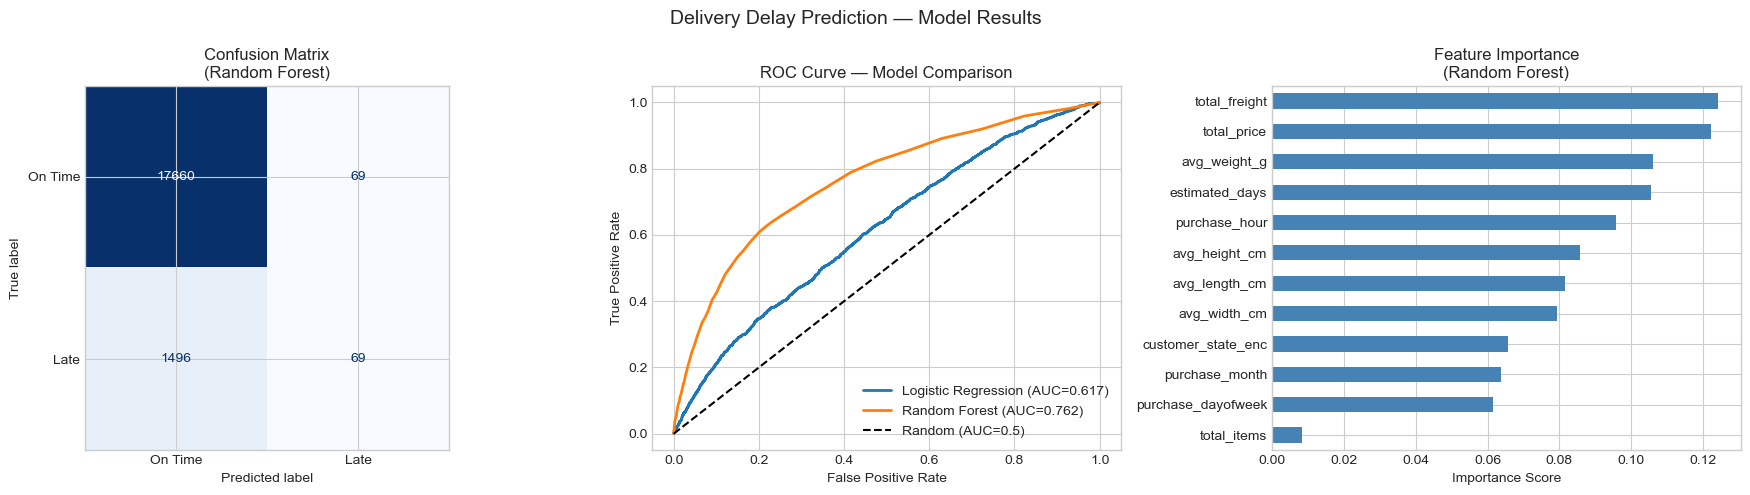

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Delivery Delay Prediction — Model Results', fontsize=14)

# 1. Confusion Matrix — Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['On Time', 'Late'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(Random Forest)')

# 2. ROC Curve — เปรียบเทียบ 2 model
for name, prob in [('Logistic Regression', y_prob_lr),
                   ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[1].plot([0,1],[0,1],'k--', label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Model Comparison')
axes[1].legend()

# 3. Feature Importance — Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature Importance\n(Random Forest)')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../reports/figures/04_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 💼 Business Impact

ถ้า Random Forest แม่น Recall = X% หมายความว่า:
- จาก 7,826 orders ที่ส่งช้าจริง สามารถจับได้ล่วงหน้า X orders
- Operations team สามารถ prioritize การจัดส่ง order กลุ่มเสี่ยงได้ทันเวลา
- ลด customer complaint และเพิ่ม review score

Feature สำคัญที่สุดในการทำนาย:
1. estimated_days — เวลาประมาณการที่ตั้งไว้นานเกินจริงหรือไม่
2. customer_state_enc — ลูกค้าอยู่ region ห่างไกลแค่ไหน
3. avg_weight_g — สินค้าหนักมากส่งช้ากว่าปกติ

In [8]:
# Export ผล prediction
result = X_test.copy()
result['actual']    = y_test.values
result['predicted'] = y_pred_rf
result['probability'] = y_prob_rf
result.to_csv('../data/processed/delay_predictions.csv', index=False)
print("✓ Export เสร็จแล้ว")

✓ Export เสร็จแล้ว


In [9]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print("ก่อน SMOTE:")
print(pd.Series(y_train).value_counts())
print("\nหลัง SMOTE:")
print(pd.Series(y_train_sm).value_counts())

ก่อน SMOTE:
is_late
0    70915
1     6261
Name: count, dtype: int64

หลัง SMOTE:
is_late
0    70915
1    70915
Name: count, dtype: int64


In [11]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = rf_smote.predict(X_test_sc)
y_prob_smote = rf_smote.predict_proba(X_test_sc)[:, 1]

print("=== Random Forest + SMOTE ===")
print(classification_report(y_test, y_pred_smote,
      target_names=['On Time', 'Late']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_smote):.3f}")

=== Random Forest + SMOTE ===
              precision    recall  f1-score   support

     On Time       0.93      0.98      0.95     17729
        Late       0.35      0.13      0.19      1565

    accuracy                           0.91     19294
   macro avg       0.64      0.56      0.57     19294
weighted avg       0.88      0.91      0.89     19294

AUC-ROC: 0.756


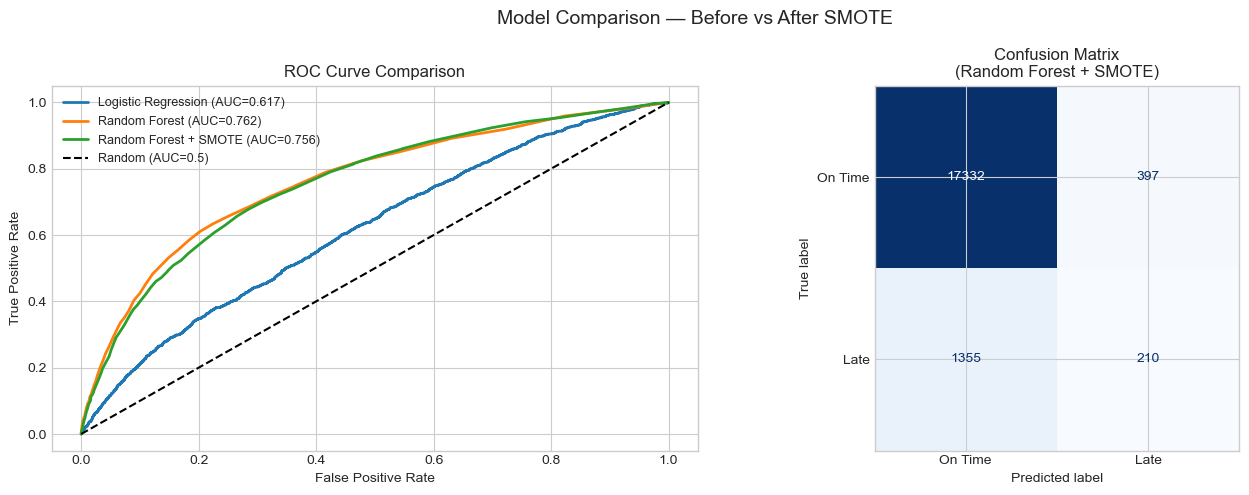

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Before vs After SMOTE', fontsize=14)

# ROC Curve เปรียบเทียบ 3 model
for name, prob in [
    ('Logistic Regression (AUC=0.617)', y_prob_lr),
    ('Random Forest (AUC=0.762)', y_prob_rf),
    ('Random Forest + SMOTE', y_prob_smote)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    label = f'{name.split("(")[0].strip()} (AUC={auc:.3f})'
    axes[0].plot(fpr, tpr, linewidth=2, label=label)

axes[0].plot([0,1],[0,1],'k--', label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(fontsize=9)

# Confusion Matrix ของ SMOTE
cm = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(cm, display_labels=['On Time', 'Late'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix\n(Random Forest + SMOTE)')

plt.tight_layout()
plt.savefig('../reports/figures/04_smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## เปรียบเทียบผล 3 Models

| Model | AUC-ROC | Late Recall | Late Precision |
|-------|---------|------------|----------------|
| Logistic Regression | 0.617 | 0% | 0% |
| Random Forest | 0.762 | 4% | 50% |
| Random Forest + SMOTE | 0.756 | 13% | 35% |

**สรุป:** SMOTE ช่วยให้ model จับ Late orders ได้เพิ่มขึ้น 3x
(จาก 69 → 210 orders) แลกกับ precision ที่ลดลงบ้าง